# Optotagging Analysis of Allen Institute Visual Behavior Neuropixels Dataset

Optotagging analysis notebook, analyzing a single session of choice from the Allen Institute Neuropixels Visual Behavior dataset. 

Reuses code from the Allen Institute Visual Behavior Optotagging Tutorial notebook.

In [1]:
import allensdk
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yaml

c:\Users\Jacob Poschl\Desktop\visb_ecephys_analysis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Adjust as needed for pre-downloaded data
config_path = Path("../configs/base.yaml")
with config_path.open("r") as f:
    config = yaml.safe_load(f)
cache_dir = Path(config["cache_dir"])

In [3]:
cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir = cache_dir)
cache.load_latest_manifest()

In [4]:
units_table = cache.get_unit_table()
channels_table = cache.get_channel_table()
probes_table = cache.get_probe_table()
behavior_sessions_table = cache.get_behavior_session_table()
ecephys_sessions_table = cache.get_ecephys_session_table()

# 1. Find Session:

In [5]:
# Find unique types of genotype & experience levels
unique_genotypes = ecephys_sessions_table["genotype"].unique().tolist()
print(f"Genotypes: {unique_genotypes}")

unique_experience_levels = ecephys_sessions_table["experience_level"].unique().tolist()
print(f"Experience Levels: {unique_experience_levels}")

Genotypes: ['wt/wt', 'Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt', 'Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt']
Experience Levels: ['Familiar', 'Novel']


### *PARAMETERS: Session Filtering*

Genotypes:
1. Wild Type
2. Sst
3. Vip
   
Experience levels:
1. Familiar
2. Novel

In [6]:
# Choose which to filter sessions by:
genotype = "Sst"
experience = "Novel"

In [7]:
sst_novel_sessions = ecephys_sessions_table.loc[
    (ecephys_sessions_table['genotype'].str.contains(genotype)) & 
    (ecephys_sessions_table['experience_level'] == experience)
    ]
sst_novel_sessions.head()

,behavior_session_id,date_of_acquisition,equipment_name,session_type,mouse_id,genotype,sex,project_code,age_in_days,unit_count,...,channel_count,structure_acronyms,image_set,prior_exposures_to_image_set,session_number,experience_level,prior_exposures_to_omissions,file_id,abnormal_histology,abnormal_activity
ecephys_session_id,,,,,,,,,,,,,,,,,,,,,
1048189115,1048221709,2020-09-03 14:16:57.913000+00:00,NP.1,EPHYS_1_images_H_3uL_reward,509808,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,M,NeuropixelVisualBehavior,264,1925,...,2304,"['APN', 'CA1', 'CA3', 'DG-mo', 'DG-po', 'DG-sg...",H,0,2,Novel,1,879,NaN,NaN
1048196054,1048222325,2020-09-03 14:25:07.290000+00:00,NP.0,EPHYS_1_images_H_3uL_reward,524925,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,F,NeuropixelVisualBehavior,166,2288,...,2304,"['APN', 'CA1', 'CA3', 'DG-mo', 'DG-po', 'DG-sg...",H,0,2,Novel,1,880,NaN,NaN
1053941483,1053960987,2020-10-01 17:03:58.362000+00:00,NP.1,EPHYS_1_images_H_3uL_reward,527749,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,M,NeuropixelVisualBehavior,180,1543,...,2304,"['APN', 'CA1', 'CA3', 'DG-mo', 'DG-po', 'DG-sg...",H,0,2,Novel,1,891,NaN,NaN
1064644573,1064666428,2020-11-19 15:18:01.372000+00:00,NP.1,EPHYS_1_images_H_3uL_reward,544456,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,M,NeuropixelVisualBehavior,120,2254,...,2304,"['APN', 'CA1', 'CA3', 'DG-mo', 'DG-po', 'DG-sg...",H,0,2,Novel,1,909,NaN,NaN
1065905010,1065929713,2020-11-24 14:21:48.847000+00:00,NP.0,EPHYS_1_images_H_3uL_reward,544358,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,F,NeuropixelVisualBehavior,126,1998,...,2304,"['APN', 'CA1', 'CA3', 'DG-mo', 'DG-po', 'DG-sg...",H,0,2,Novel,1,912,NaN,NaN


In [8]:
# Choose a single session to analyze from the above dataset
session_id = 1048189115
session = cache.get_ecephys_session(ecephys_session_id = session_id)
session.metadata

c:\Users\Jacob Poschl\Desktop\visb_ecephys_analysis\.venv\lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


{'equipment_name': 'NP.1',
 'sex': 'M',
 'age_in_days': 264,
 'stimulus_frame_rate': 60.0,
 'session_type': 'EPHYS_1_images_H_3uL_reward',
 'date_of_acquisition': datetime.datetime(2020, 9, 3, 21, 16, 57, tzinfo=tzutc()),
 'reporter_line': 'Ai32(RCL-ChR2(H134R)_EYFP)',
 'cre_line': 'Sst-IRES-Cre',
 'behavior_session_uuid': UUID('7281cf85-c09f-46f0-a836-8049b6851846'),
 'driver_line': ['Sst-IRES-Cre'],
 'mouse_id': '509808',
 'project_code': 'Not Available',
 'full_genotype': 'Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt',
 'behavior_session_id': 1048221709,
 'ecephys_session_id': 1048189115}

# 2. Handle Units

In [9]:
# Extract Units & Channels from session
units = session.get_units()
print(f"Unit Columns: \n{units.columns.tolist()}")
channels = session.get_channels()
print(f"\nChannel Columns: \n{channels.columns.tolist()}")
units = units.merge(channels, left_on = 'peak_channel_id', right_index = True)

Unit Columns: 
['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cluster_id', 'cumulative_drift', 'd_prime', 'firing_rate', 'isi_violations', 'isolation_distance', 'l_ratio', 'local_index', 'max_drift', 'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio', 'quality', 'recovery_slope', 'repolarization_slope', 'silhouette_score', 'snr', 'spread', 'velocity_above', 'velocity_below', 'waveform_duration']

Channel Columns: 
['anterior_posterior_ccf_coordinate', 'dorsal_ventral_ccf_coordinate', 'filtering', 'left_right_ccf_coordinate', 'probe_channel_number', 'probe_horizontal_position', 'probe_id', 'probe_vertical_position', 'structure_acronym']


### *PARAMETERS: Unit Filtering*

In [10]:
# Adjust depending on filtering choice
snr_min = 1.0
isi_violations_max = 1.0
firing_rate_min = 0.1
quality = "good"
region = "VIS"

In [11]:
# Filter units
good_unit_filter = (
    (units['snr'] > snr_min ) & 
    (units['isi_violations'] < isi_violations_max) & 
    (units['firing_rate'] > firing_rate_min) &
    (units['quality'] == quality)
)

units = units.sort_values('probe_vertical_position', ascending = False)
filtered_units = units[good_unit_filter & units['structure_acronym'].str.contains(region)]

C:\Users\Jacob Poschl\AppData\Local\Temp\ipykernel_17604\2743133485.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_units = units[good_unit_filter & units['structure_acronym'].str.contains(region)]


# 3. Align Spikes with Light Pulses

In [12]:
# Extract spike times
spike_times = session.spike_times

# Extract optotagging table
opto_table = session.optotagging_table
opto_table.head()

,start_time,condition,level,stop_time,stimulus_name,duration
id,,,,,,
0,8806.67613,half-period of a cosine wave,1.00,8807.67613,raised_cosine,1.00
1,8808.61513,half-period of a cosine wave,1.70,8809.61513,raised_cosine,1.00
2,8810.72613,half-period of a cosine wave,1.00,8811.72613,raised_cosine,1.00
3,8812.80593,a single square pulse,0.78,8812.81593,pulse,0.01
4,8814.74588,half-period of a cosine wave,1.70,8815.74588,raised_cosine,1.00


Extracted from allen institute optotagging notebook

In [13]:
def makePSTH(spikes , startTimes, windowDur, binSize = 0.001):
    # Create empty bins
    bins = np.arange( 0 , windowDur + binSize, binSize)

    # Create empty counts in those bins
    counts = np.zeros(bins.size - 1)

    # Fill in the counts with real spikes
    for start in startTimes:
        startInd = np.searchsorted(spikes , start)
        endInd = np.searchsorted(spikes , start + windowDur)
        # Find counts of spikes for each bin, add to summed counts
        counts = counts + np.histogram(spikes[startInd : endInd] - start , bins)[0]

    # Convert into average spike counts per trial in each bin
    counts = counts / len(startTimes)

    # Convert from count / bin -> spikes / second (Hz)
    return (counts / binSize) , bins[:-1]

In [14]:
def make_neuron_time_trials_array(units , stim_table , time_before , trial_duration , bin_size = 0.001):
    
    # Dimensions of outputs
    neuron_number = len(units)
    trial_number = len(stim_table)
    num_time_bins = int(trial_duration / bin_size)

    # Initialize the unit array with zeros
    unit_array = np.zeros((neuron_number , num_time_bins , trial_number))

    # Loop through units and trials and store spike counts per time bin
    for u_counter , (iu, unit) in enumerate(units.iterrows()):

        # Extract spike times for unit
        unit_spike_times = spike_times[iu]

        # For each trial, make a PSTH for this unit
        for t_counter , (it , trial) in enumerate(stim_table.iterrows()):
            
            trial_start = trial.start_time - time_before

            # Make the PSTH for this unit
            unit_array[u_counter, : , t_counter] = makePSTH(unit_spike_times, [trial_start], trial_duration, binSize = bin_size)[0]

    # Create time vector that labels the time axis
    time_vector = np.arange(num_time_bins) * bin_size - time_before

    return unit_array , time_vector

### *PARAMETERS: Bins & Trial Timing*

In [18]:
opto_table['duration'].unique()

array([1.  , 0.01])

In [15]:
# Adjust
time_before_laser = 0.5
trial_duration = 1.5
bin_size = 0.001

In [16]:
time_array = np.arange(-time_before_laser,trial_duration-time_before_laser,bin_size)

# opto_array (Neurons x Time Bins x Trials)
opto_array,time = make_neuron_time_trials_array(filtered_units, opto_table, time_before_laser, trial_duration, bin_size)

In [20]:
# Extract the trials with the shortest pulse & highest pulse level
duration = opto_table.duration.min()
level = opto_table.level.max()

sel_trials = (
    (opto_table['duration'] == duration) &
    (opto_table['level'] == level)
).values

# Average spikes across selected trials
mean_opto_response = np.nanmean(opto_array[: , : , sel_trials], 2)

(-10.0, 20.0)

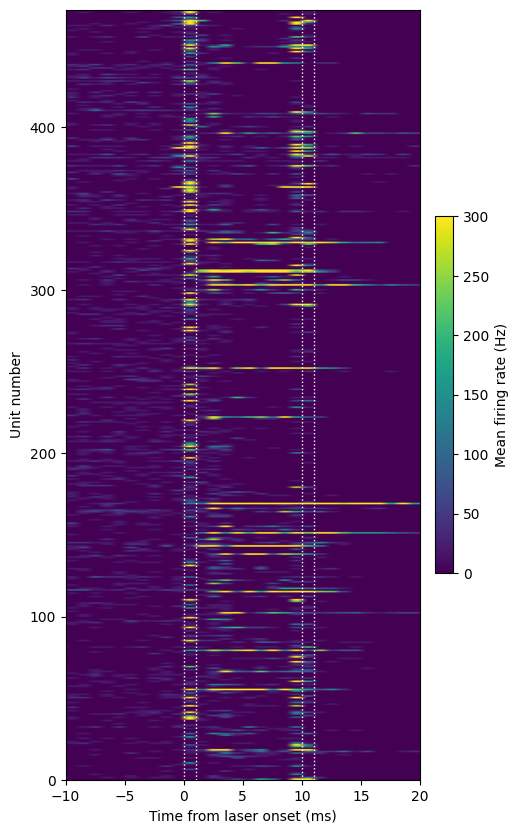

In [23]:
# Find the time indices for a short window before and after optogenetic stimulation
time_idx = (time_array>=-0.05)&(time_array<0.05)

# Now plot a heatmap across units showing how they responded to the laser
fig,ax=plt.subplots(1,1)
fig.set_size_inches((5,10))

# Note: when using imshow, the "extent" parameter should match your data axes extent=[xmin, xmax, ymin, ymax].
# Since our bins are 1ms, and we are plotting from -50ms to +50ms, xmin=-50 and xmax=+50
# We also specify the y axis in terms of units, ymin=0 and ymax= the number of units we are plotting
im=ax.imshow(mean_opto_response[:,time_idx],
             extent=[-50, 50, 0, mean_opto_response.shape[0]], 
             origin='lower', aspect='auto')
min_clim_val = 0
max_clim_val = 300
im.set_clim([min_clim_val, max_clim_val])    
[ax.axvline(bound, linestyle=':', color='white', linewidth=1.0)\
     for bound in [0,1,11, 10]]
ax.set_xlabel('Time from laser onset (ms)')
ax.set_ylabel('Unit number')
cb = plt.colorbar(im,fraction=0.046, pad=0.04)
cb.set_label('Mean firing rate (Hz)')

ax.set_xlim([-10,20])

In [37]:
# Compute neurons that show an increased firing rate relative to baseline

# Before the light turns on
baseline_time_idx = (time_array >= -0.010) & (time_array < -0.002)
# Average over the time window to get the baseline firing rate for each unit
baseline_rate = np.mean(mean_opto_response[: , baseline_time_idx], 1)

# After the light turns on
evoked_rate_idx = (time_array >= 0.001) & (time_array < 0.009)
# Averaged over teh time window for evoked firing rate for each unit
evoked_rate = np.mean(mean_opto_response[: , evoked_rate_idx], 1)

### PARAMETERS: *Optotagging Criteria*

In [44]:
increase_in_FR = 5
min_evoked_rate = 50

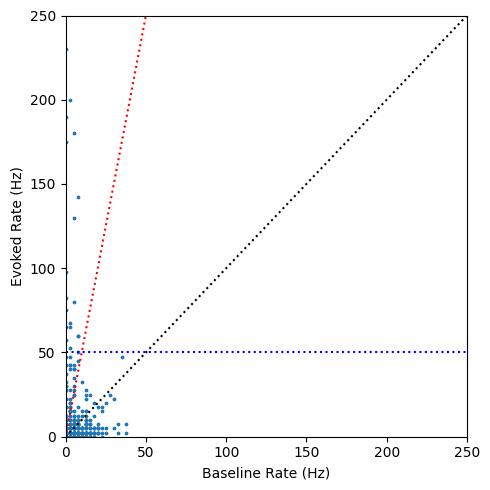

In [45]:
# Plot the evoked vs baseline rates as a scatter plot to visualize neurons that show a significant increase 
fig , ax = plt.subplots(1 , 1 , figsize = (5 ,5 ))
ax.scatter(baseline_rate , evoked_rate , s = 3)
axis_limit = 250
ax.plot([0 , axis_limit], [0 , axis_limit] , ":k")
ax.plot([0 , axis_limit], [0 , axis_limit * increase_in_FR], ':r')
ax.axhline(min_evoked_rate, color = 'b', linestyle = ':')
ax.set_xlim([0 , axis_limit])
ax.set_ylim([0 , axis_limit])
ax.set_xlabel('Baseline Rate (Hz)')
ax.set_ylabel('Evoked Rate (Hz)')
fig.tight_layout()

In [ ]:
# Extract neurons that satisfy our optotagging criteria
# Evoked rate must exceed minimum AND must be >increase_in_FR times the baseline (adding 1 to prevent divide-by-zero)
cre_pos_idx = (evoked_rate > min_evoked_rate) & ((evoked_rate / (baseline_rate + 1)) > increase_in_FR)
cre_pos_unit_ids = filtered_units[cre_pos_idx == True].index
cre_pos_units = filtered_units.loc[cre_pos_unit_ids]
cre_pos_units.describe()

In [51]:
# Select the putative cre-positive units
cre_pos_array = opto_array[cre_pos_idx , : , :]
# Compute the average over the selected trials
mean_opto_responses = np.nanmean(cre_pos_array[ : , : , sel_trials] , 2)

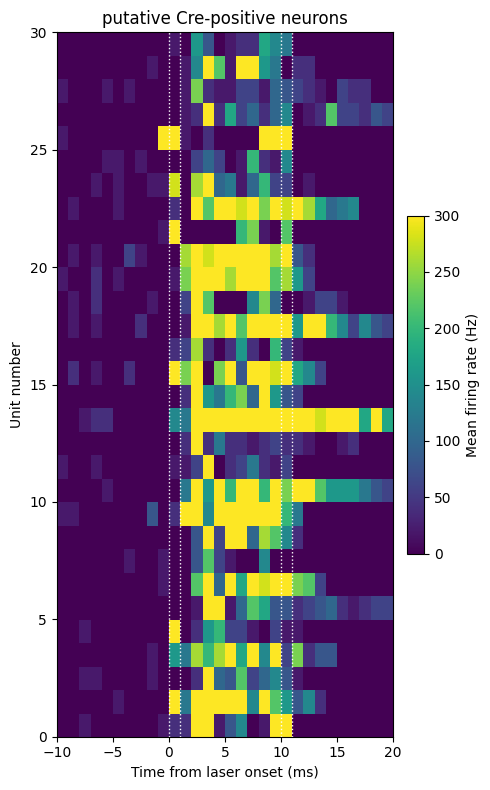

In [52]:
# Plot the cre-positive neurons
time_idx = (time_array>=-0.05)&(time_array<0.05)

fig,ax=plt.subplots(1,1)
fig.set_size_inches((5,8))

im=ax.imshow(mean_opto_responses[:,time_idx],
             extent=[-50, 50, 0, mean_opto_responses.shape[0]], 
             origin='lower', aspect='auto')
min_clim_val = 0
max_clim_val = 300
im.set_clim([min_clim_val, max_clim_val])    
[ax.axvline(bound, linestyle=':', color='white', linewidth=1.0)\
     for bound in [0,1,11,10]]
ax.set_xlabel('Time from laser onset (ms)')
ax.set_ylabel('Unit number')
cb = plt.colorbar(im,fraction=0.046, pad=0.04)
cb.set_label('Mean firing rate (Hz)')

ax.set_xlim([-10,20])
ax.set_title('putative Cre-positive neurons')
fig.tight_layout()

In [56]:
# Find the cre-negative units
cre_neg_idx = ~cre_pos_idx
cre_neg_unit_ids = filtered_units[cre_neg_idx == True].index

cre_neg_units = filtered_units.loc[cre_neg_unit_ids]

cre_neg_array = opto_array[cre_neg_idx, : , :]
mean_opto_responses = np.nanmean(cre_neg_array[ : , : , sel_trials] , 2)

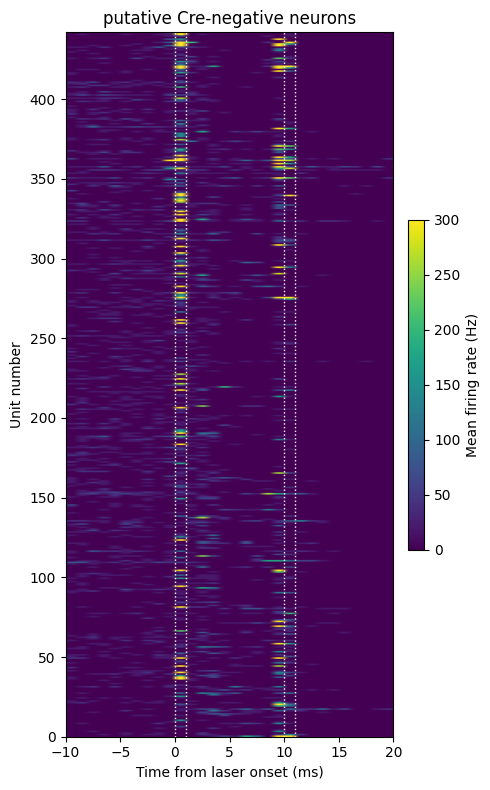

In [58]:
# Plot our putative cre-negative units
fig,ax=plt.subplots(1,1)
fig.set_size_inches((5,8))

im=ax.imshow(mean_opto_responses[:,time_idx],
             extent=[-50, 50, 0, mean_opto_responses.shape[0]], 
             origin='lower', aspect='auto')
min_clim_val = 0
max_clim_val = 300
im.set_clim([min_clim_val, max_clim_val])    
[ax.axvline(bound, linestyle=':', color='white', linewidth=1.0)\
     for bound in [0,1,10,11]]
ax.set_xlabel('Time from laser onset (ms)')
ax.set_ylabel('Unit number')
cb = plt.colorbar(im,fraction=0.046, pad=0.04)
cb.set_label('Mean firing rate (Hz)')

ax.set_xlim([-10,20])
ax.set_title('putative Cre-negative neurons')
fig.tight_layout()

# 4. Plot Cre-Negative & Cre-Positive Neuronal Responses to Novel / Familiar Images

In [60]:
stimulus_presentations = session.stimulus_presentations

In [63]:
session_id = session.metadata['ecephys_session_id']

# Find novel experience levels
is_novel_image_set = ecephys_sessions_table.loc[session_id]['experience_level'] == 'Novel'

IMAGE_SET_KEY={
                'G' : ['im012_r', 'im036_r', 'im044_r', 
                    'im047_r', 'im078_r', 'im115_r'],
                'H' : ['im005_r', 'im024_r', 'im034_r', 
                    'im087_r', 'im104_r', 'im114_r'],
                'shared' : ['im083_r', 'im111_r'],
                'omitted' : 'omitted'
                }

In [64]:
def getImageNovelty(image_name):
    '''
    Function to help annotate the stimulus_presentations table
    to indicate the following info:
        1) whether a given image was:
            a) unique to the G set
            b) unique to the H set
            c) shared across G and H
            d) omitted
        2) whether the image was novel to the mouse
    
    Meant to be run on the image names of the stimulus_presentations table
    
    OUTPUT:
        Tuple indicating (image_set, image_novelty) for one 
        row of the stimulus_presentations table

    '''
    # First check that this image is one of the Natural Images used
    image_in_image_set = any([np.isin(image_name, imset) \
                              for _,imset in IMAGE_SET_KEY.items()]) 
    if not image_in_image_set:
        return np.nan, np.nan

    #Get the image set for this image
    image_set_for_this_image = [name for name, image_set in IMAGE_SET_KEY.items()\
                                if image_name in image_set][0]
    
    #Get the image novelty for this image
    if image_set_for_this_image == 'omitted':
        novelty_for_this_image = np.nan
    else:
        novelty_for_this_image = (is_novel_image_set) and \
                            (np.isin(image_set_for_this_image, ['G', 'H']))
    

    return image_set_for_this_image, novelty_for_this_image

In [65]:
# Find novel images
image_info = stimulus_presentations.apply(lambda row : getImageNovelty(row['image_name']), axis = 1)
stimulus_presentations['image_set'] = [i[0] for i in image_info]
stimulus_presentations['is_novel'] = [i[1] for i in image_info]

c:\Users\Jacob Poschl\Desktop\visb_ecephys_analysis\.venv\lib\site-packages\numpy\lib\arraysetops.py:612: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


### PARAMETERS: *Cre+ vs Cre- Comparison Bins & Trial Timing*

In [67]:
time_before_flash = 1.0
trial_duration = 2.0
bin_size = 0.005

In [66]:
# Find stimulus information for active & changing
task_stim_table = stimulus_presentations[stimulus_presentations['active'] &
                                         stimulus_presentations['is_change']]



time_array = np.arange(-time_before_flash, trial_duration - time_before_flash, bin_size)

cre_pos_stim_array,time = make_neuron_time_trials_array(cre_pos_units, task_stim_table, time_before_flash, trial_duration, bin_size)
cre_neg_stim_array,time = make_neuron_time_trials_array(cre_neg_units, task_stim_table, time_before_flash, trial_duration, bin_size)

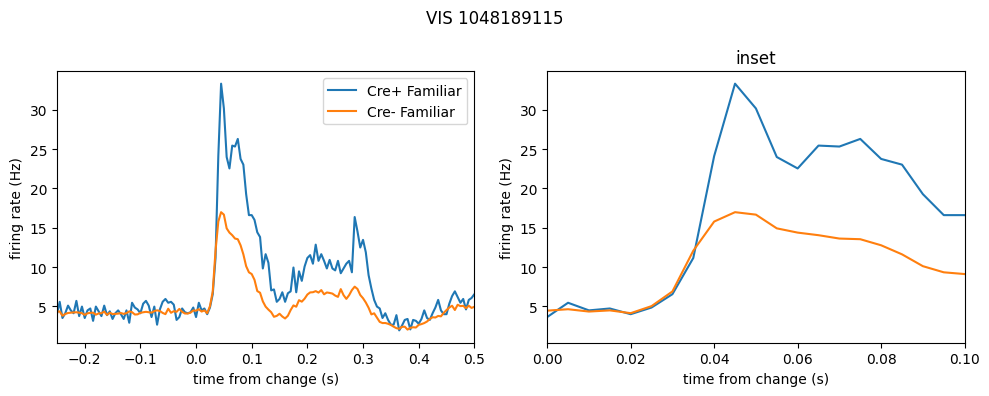

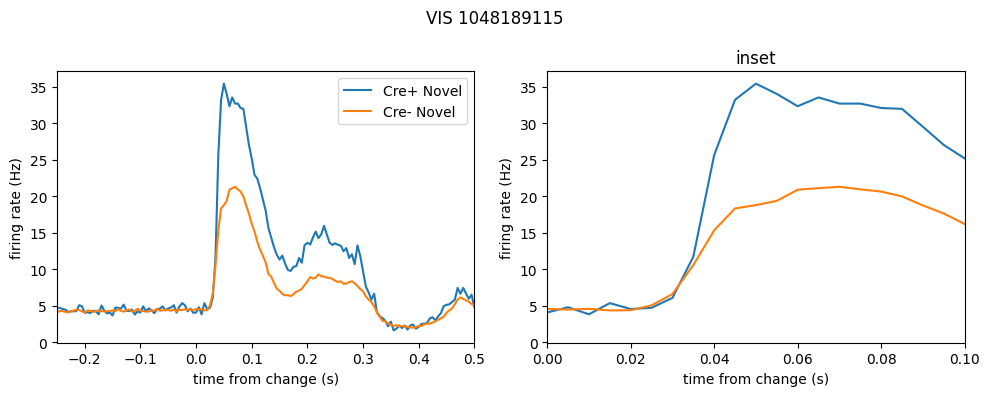

In [68]:
# Plot our Cre+ vs Cre- respones to familiar & novel image changes
for isnovel in [False, True]:

    fig, axes = plt.subplots(1,2)
    fig.set_size_inches([10, 4])
    fig.suptitle('VIS '+str(session_id))

    # First let's find the trial ids for the relevant change stimuli
    trial_ids = task_stim_table[(task_stim_table['is_novel']==isnovel)].index
    
    # Because our 3D arrays are no longer linked to trial_ids, we need to find their index in the task_stim_table:
    trial_indexer = task_stim_table.index.get_indexer(trial_ids)

    # Now let's use those trial ids to select the corresponding cre positive and cre negative unit tables
    cre_pos_relevant_trials = cre_pos_stim_array[:,:,trial_indexer]
    cre_neg_relevant_trials = cre_neg_stim_array[:,:,trial_indexer]

    # Let's now take the mean over units and trials
    cre_pos_mean_over_trials = np.mean(cre_pos_relevant_trials,axis=(0,2))
    cre_neg_mean_over_trials = np.mean(cre_neg_relevant_trials,axis=(0,2))

    # Now plot. We're plotting twice to show two time scales, and plotting Cre+ and Cre- as separate lines
    [ax.plot(time_array, cre_pos_mean_over_trials) for ax in axes]
    [ax.plot(time_array, cre_neg_mean_over_trials) for ax in axes]

    xlims = ([-0.25, 0.5], [0, 0.1])
    for ax, xlim in zip(axes, xlims):
        ax.set_xlabel('time from change (s)')
        ax.set_ylabel('firing rate (Hz)')
        ax.set_xlim(xlim)

    axes[1].set_title('inset')

    if isnovel:
        axes[0].legend(['Cre+ Novel', 'Cre- Novel'])
    else:
        axes[0].legend(['Cre+ Familiar', 'Cre- Familiar'])

    fig.tight_layout()